# 🚗 Car Price Prediction with Machine Learning

This project develops machine learning regression models to predict the selling price of used cars based on their characteristics. The dataset includes showroom prices, kilometers driven, age of the car, fuel type, transmission type, owner history, and seller type.

## 📊 Dataset Features
- `Car_Name`: Brand and model of the car.
- `Year`: Year of manufacture.
- `Selling_Price`: The price the owner wants to sell the car for (Target Variable, in Lakhs).
- `Present_Price`: Showroom price of the new car (in Lakhs).
- `Driven_kms`: Number of kilometers driven.
- `Fuel_Type`: Fuel type (Petrol, Diesel, CNG).
- `Selling_type`: Seller type (Dealer, Individual).
- `Transmission`: Transmission type (Manual, Automatic).
- `Owner`: Number of previous owners (0, 1, 3).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [2]:
# Load the dataset
df = pd.read_csv("car data.csv")

# Display basic details
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Check for missing values and description
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Dataset Summary Description ---")
print(df.describe())

--- Missing Values ---
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

--- Dataset Summary Description ---
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


## 📈 Exploratory Data Analysis (EDA)
Let's visualize the selling price distributions and the relationship between Present Price and Selling Price.

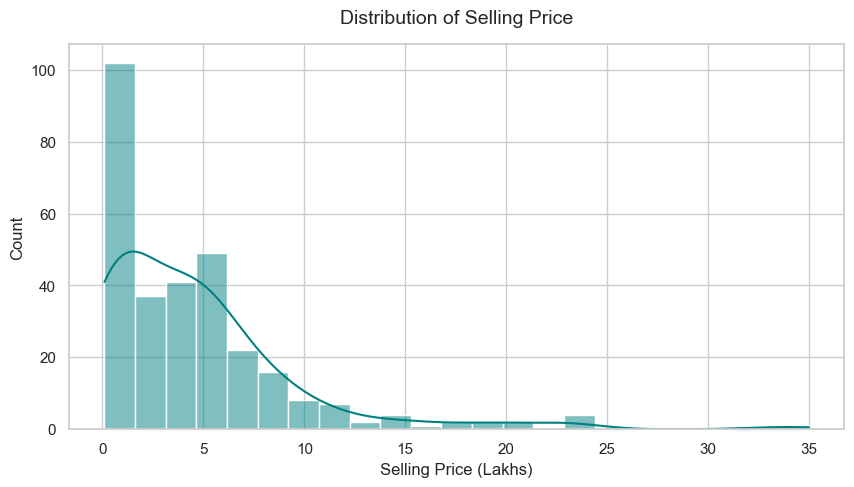

In [4]:
# 1. Distribution of Selling Price
plt.figure(figsize=(10, 5))
sns.histplot(df['Selling_Price'], kde=True, color='teal')
plt.title("Distribution of Selling Price", fontsize=14, pad=15)
plt.xlabel("Selling Price (Lakhs)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.savefig("selling_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

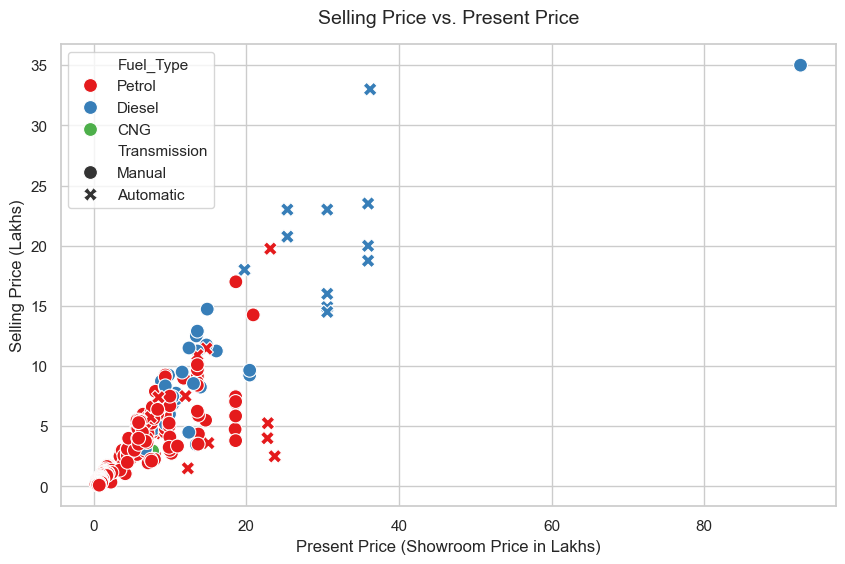

In [5]:
# 2. Relationship between Present Price and Selling Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type', palette='Set1', style='Transmission', s=100)
plt.title("Selling Price vs. Present Price", fontsize=14, pad=15)
plt.xlabel("Present Price (Showroom Price in Lakhs)", fontsize=12)
plt.ylabel("Selling Price (Lakhs)", fontsize=12)
plt.savefig("price_relationship.png", dpi=300, bbox_inches="tight")
plt.show()

## ⚙️ Feature Engineering & Preprocessing

In [6]:
# Create 'Car_Age' from Year
# Since the dataset's maximum year is 2018, we calculate age relative to 2018
max_year = df['Year'].max()
df['Car_Age'] = max_year - df['Year']

# Drop 'Car_Name' and 'Year' as they are not needed for prediction
df_ml = df.drop(columns=['Car_Name', 'Year'])
df_ml.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,4
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,5
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,1
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,7
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,4


In [7]:
# One-Hot Encoding categorical features
# Convert boolean to int (0/1) for encoded columns
df_encoded = pd.get_dummies(df_ml, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

df_encoded.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,4,0,1,0,1
1,4.75,9.54,43000,0,5,1,0,0,1
2,7.25,9.85,6900,0,1,0,1,0,1
3,2.85,4.15,5200,0,7,0,1,0,1
4,4.60,6.87,42450,0,4,1,0,0,1


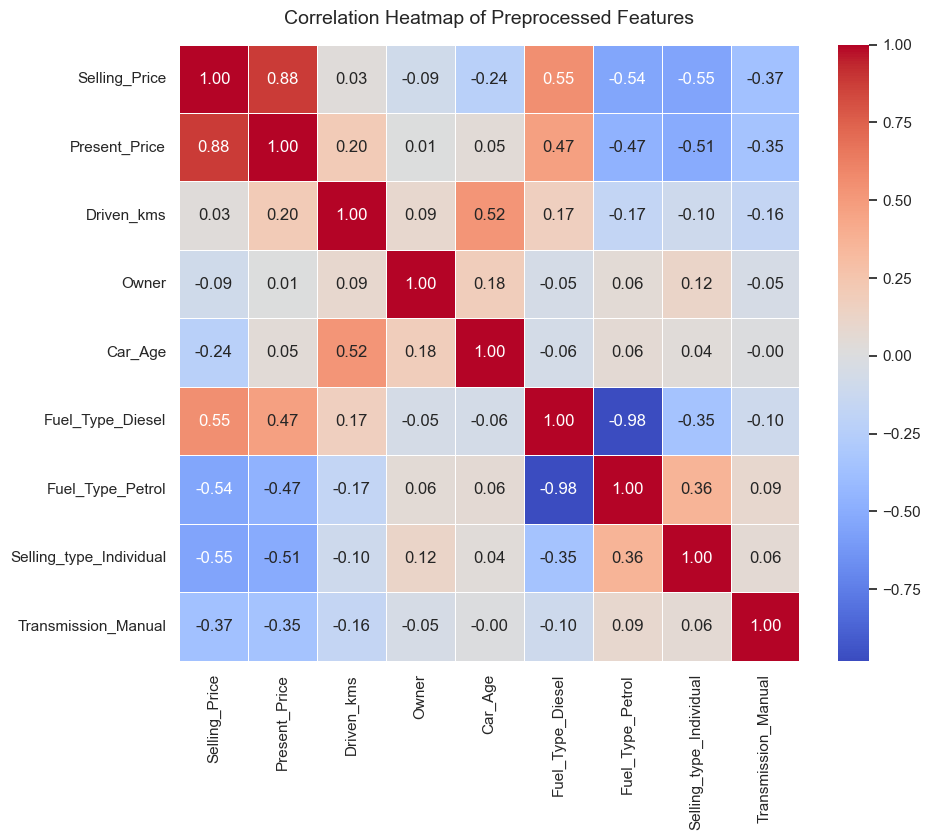

In [8]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Preprocessed Features", fontsize=14, pad=15)
plt.savefig("feature_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Splitting Features and Target
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

# Split into Train & Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 240
Testing set size: 61


## 🤖 Model Training & Comparison
We train and compare four models:
1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**
4. **Gradient Boosting Regressor**

In [10]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Dictionary to store metrics
metrics = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    metrics[name] = {"R2": r2, "MAE": mae, "RMSE": rmse}
    
    print(f"=== {name} ===")
    print(f"R2 Score:  {r2:.4f}")
    print(f"MAE:       {mae:.4f} Lakhs")
    print(f"RMSE:      {rmse:.4f} Lakhs")
    print("-" * 40)

=== Linear Regression ===
R2 Score:  0.8489
MAE:       1.2164 Lakhs
RMSE:      1.8658 Lakhs
----------------------------------------
=== Decision Tree ===
R2 Score:  0.9455
MAE:       0.7334 Lakhs
RMSE:      1.1207 Lakhs
----------------------------------------
=== Random Forest ===
R2 Score:  0.9595
MAE:       0.6369 Lakhs
RMSE:      0.9664 Lakhs
----------------------------------------
=== Gradient Boosting ===
R2 Score:  0.9617
MAE:       0.5899 Lakhs
RMSE:      0.9394 Lakhs
----------------------------------------


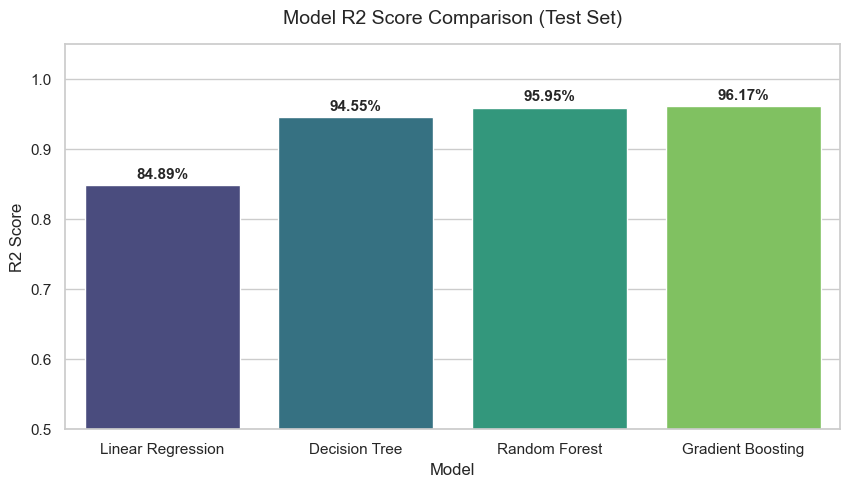

In [11]:
# Plot R2 score comparison
model_names = list(metrics.keys())
r2_scores = [metrics[name]["R2"] for name in model_names]

plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=r2_scores, palette='viridis', hue=model_names, legend=False)
plt.ylim(0.5, 1.05)
plt.title("Model R2 Score Comparison (Test Set)", fontsize=14, pad=15)
plt.ylabel("R2 Score", fontsize=12)
plt.xlabel("Model", fontsize=12)

for i, val in enumerate(r2_scores):
    plt.text(i, val + 0.01, f"{val:.2%}", ha='center', fontweight='bold', fontsize=11)

plt.savefig("model_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

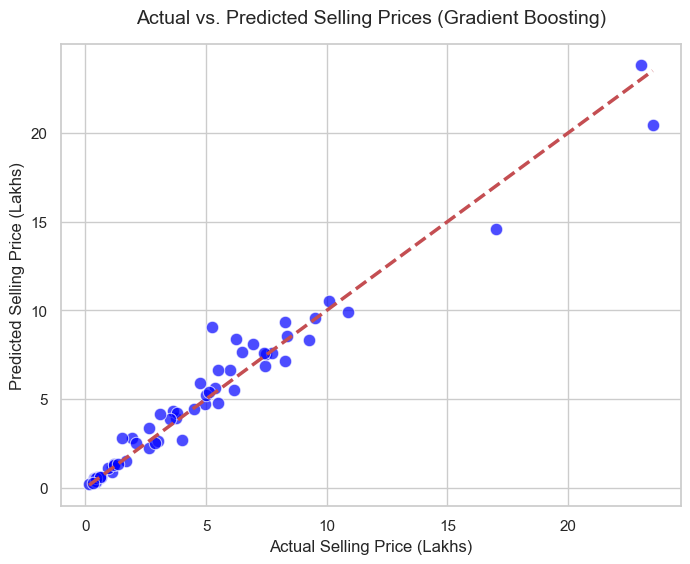

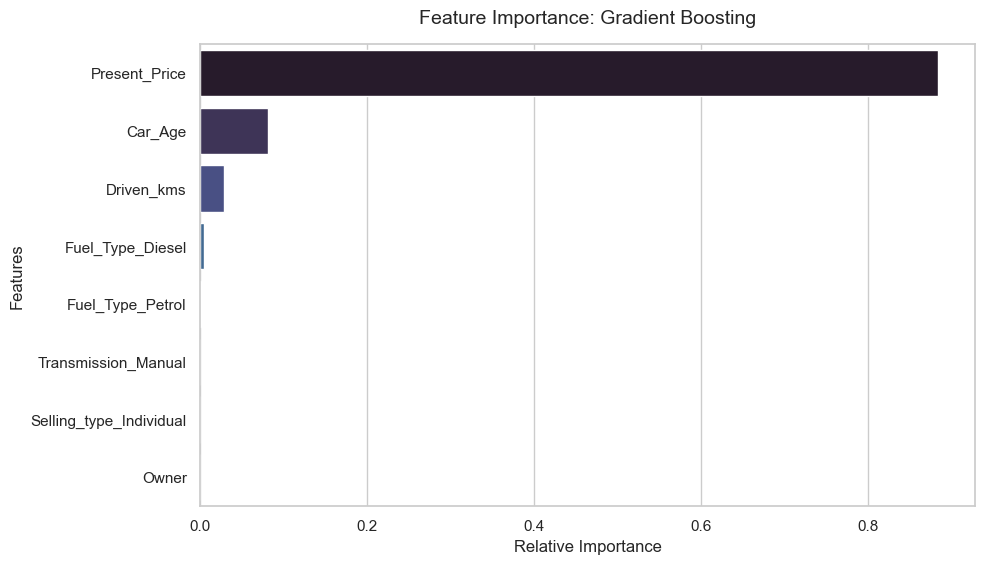

The best performing model on the test set is: Gradient Boosting with an R2 Score of 96.17%


In [12]:
# Find the best model based on R2 score
best_model_name = max(metrics, key=lambda name: metrics[name]["R2"])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

# 1. Actual vs. Predicted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, color='blue', alpha=0.7, s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5)
plt.title(f"Actual vs. Predicted Selling Prices ({best_model_name})", fontsize=14, pad=15)
plt.xlabel("Actual Selling Price (Lakhs)", fontsize=12)
plt.ylabel("Predicted Selling Price (Lakhs)", fontsize=12)
plt.savefig("actual_vs_predicted_selling_prices.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Feature Importance for the best model (Tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=X.columns[indices], palette='mako', hue=X.columns[indices], legend=False)
    plt.title(f"Feature Importance: {best_model_name}", fontsize=14, pad=15)
    plt.xlabel("Relative Importance", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.savefig("best_model_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Feature importances are not available for this model.")

print(f"The best performing model on the test set is: {best_model_name} with an R2 Score of {metrics[best_model_name]['R2']:.2%}")